In [199]:
import numpy as np
from scipy import constants
import pandas as pd
import matplotlib.pyplot as plt
from tweezer_functions import * 
from IonChainTools import *
from scipy.optimize import fsolve
import matplotlib.colors as mcolors
import matplotlib.colorbar as mcolorbar
from scipy.optimize import fsolve
from scipy.optimize import curve_fit
from scipy.optimize import minimize
import matplotlib.ticker as ticker
import itertools

#Constants in SI units
eps0 = constants.epsilon_0 
m = 39.9626*constants.atomic_mass
c = constants.c
e = constants.e
hbar = constants.hbar
pi = np.pi

# setting up parameters that we're not changing
qubit_wavelength = 729e-9
tweezer_wavelength = 532e-9
omega_tweezer = 2*pi*c/tweezer_wavelength
df = pd.read_csv("S_P_only.csv",sep = ",",encoding = "UTF-8")
lambdares = np.array(df["wavelength (nm)"])*1e-9
omega_res = 2*pi*c/lambdares
linewidths = np.array(df["A_ki (s^-1)"])
lifetimes = linewidths
print(linewidths)
#test

[1.47e+08 1.40e+08]


In [200]:
P_opt = np.linspace(0,10,1) #W
w0 = 1e-6 #m
N = 3 #change me for a different number of ions

In [201]:
pot = potential(omega_tweezer,linewidths,omega_res,P_opt,w0)
w_tw_r = omega_tweezer_r(pot,w0,m) 
print("f_tw_r = ",w_tw_r/(2*pi*1e3),"kHz")

f_tw_r =  [0.] kHz


In [202]:
f_rf_r = 1e6 #Hz
w_rf_r = f_rf_r*2*pi
ueq = ion_spacing(N,f_rf_r)[0]
f_rf_r_list = np.full(N,f_rf_r)
w_rf_r_list = np.full(N,w_rf_r)


In [203]:
eta(mode_calc_r(m, w_rf_r_list, ueq, N),729.147e-9,N)[0]

[0.140241262793494, 0.14024126279349566, 0.14024126279349583]

In [207]:
def lamb_dicke(qubit_wavelength,omega_rf):
    """Inputs:
        qubit wavelength -- float of qubit wavelength, ex 729e-9 for Ca 40
        omega_rf -- secular frequency of trap in whatever direction you're considering (2*pi*Hz)

        This function assumes the incoming beam has a 100% projection on the direction you're considering. 
        If you want what the lamb dicke parameter would be for an ion in a multi-ion chain then you have to scale it by its participation
        Outputs:
        Lamb -Dicke parameter for a single ion
    """


    k = (2*pi)/qubit_wavelength
    np.sqrt((hbar*k**2) /(2*m*omega_rf) )

In [252]:
def tweezer_combos_full_radial(omega_tweezer, linewidths, omega_res, m, mode_calc_r, N, f_rf_r, P_opt, w0):
    """
    Compute all tweezer combinations and corresponding radial mode frequencies,
    including power dependence and tweezed/untweezed mode separation.
    """

    pi = np.pi
    rows = []

    for P in P_opt:
        pot = potential(omega_tweezer, linewidths, omega_res, P, w0)
        w_tw_r = omega_tweezer_r(pot, w0, m)
        f_tw_r = w_tw_r / (2 * pi * 1e3)
        print(f"P = {P:.3f} W → f_tw_r = {f_tw_r:.3f} kHz")

        # RF trap setup
        w_rf_r = f_rf_r * 2 * pi
        ueq = ion_spacing(N, f_rf_r)[0]
        w_rf_r_list = np.full(N, w_rf_r)

        # Loop through all tweezer combinations
        for r in range(0, N):
            for positions in itertools.combinations(range(N), r):
                combo = []
                for i in range(N):
                    if i in positions:
                        combo.append(np.sqrt(w_tw_r**2 + w_rf_r_list[i]**2))
                    else:
                        combo.append(w_rf_r_list[i])
                combo = np.array(combo)

                # Compute radial modes
                modes = mode_calc_r(m, combo, ueq, N)
                tweezed_radial_modes = eta(modes, 729.147e-9, N)

                # Flatten modes
                Mode0 = np.ravel(tweezed_radial_modes[0])
                Mode1 = np.ravel(tweezed_radial_modes[1])
                Mode2 = np.ravel(tweezed_radial_modes[2])

                # Quadrature sums
                Mode0_sum = np.sqrt(np.sum(Mode0**2))
                Mode1_sum = np.sqrt(np.sum(Mode1**2))
                Mode2_sum = np.sqrt(np.sum(Mode2**2))

                # Function to get max value and index
                def max_with_index(arr):
                    arr = np.ravel(arr)
                    idx = np.argmax(arr)
                    return arr[idx], idx

                # Function to get max excluding tweezed ions
                def max_no_tweeze(arr, tweezed, N):
                    arr = np.ravel(arr)
                    ion_indices = np.arange(N)
                    mask = ~np.isin(ion_indices, tweezed)
                    if np.any(mask):
                        arr_untweezed = arr[mask]
                        ion_untweezed = ion_indices[mask]
                        idx_local = np.argmax(arr_untweezed)
                        return arr_untweezed[idx_local], ion_untweezed[idx_local]
                    else:
                        return np.nan, np.nan

                # Function to compute quadrature sum excluding tweezed ions
                def sum_no_tweeze(arr, tweezed, N):
                    arr = np.ravel(arr)
                    ion_indices = np.arange(N)
                    untweezed_mask = ~np.isin(ion_indices, tweezed)
                    if np.any(untweezed_mask):
                        return np.sqrt(np.sum(arr[untweezed_mask]**2))
                    else:
                        return np.nan

                # Max and untweezed max for all 3 modes
                Mode0_max, Mode0_max_index = max_with_index(Mode0)
                Mode1_max, Mode1_max_index = max_with_index(Mode1)
                Mode2_max, Mode2_max_index = max_with_index(Mode2)

                Mode0_max_no_tweeze, Mode0_max_no_tweeze_index = max_no_tweeze(Mode0, positions, N)
                Mode1_max_no_tweeze, Mode1_max_no_tweeze_index = max_no_tweeze(Mode1, positions, N)
                Mode2_max_no_tweeze, Mode2_max_no_tweeze_index = max_no_tweeze(Mode2, positions, N)

                # Quadrature sums excluding tweezed ions
                Mode0_sum_no_tweeze = sum_no_tweeze(Mode0, positions, N)
                Mode1_sum_no_tweeze = sum_no_tweeze(Mode1, positions, N)
                Mode2_sum_no_tweeze = sum_no_tweeze(Mode2, positions, N)

                # Store results
                rows.append({
                    "P_opt (W)": P,
                    "Ions tweezed": positions,
                    "Combined radial frequencies": combo,
                    "radial_modes": tweezed_radial_modes,
                    "Mode0": Mode0,
                    "Mode1": Mode1,
                    "Mode2": Mode2,
                    "Mode0_sum": Mode0_sum,
                    "Mode1_sum": Mode1_sum,
                    "Mode2_sum": Mode2_sum,
                    "Mode0_sum_no_tweeze": Mode0_sum_no_tweeze,
                    "Mode1_sum_no_tweeze": Mode1_sum_no_tweeze,
                    "Mode2_sum_no_tweeze": Mode2_sum_no_tweeze,
                    "Mode0_max": Mode0_max,
                    "Mode0_max_index": Mode0_max_index,
                    "Mode1_max": Mode1_max,
                    "Mode1_max_index": Mode1_max_index,
                    "Mode2_max": Mode2_max,
                    "Mode2_max_index": Mode2_max_index,
                    "Mode0_max_no_tweeze": Mode0_max_no_tweeze,
                    "Mode0_max_no_tweeze_index": Mode0_max_no_tweeze_index,
                    "Mode1_max_no_tweeze": Mode1_max_no_tweeze,
                    "Mode1_max_no_tweeze_index": Mode1_max_no_tweeze_index,
                    "Mode2_max_no_tweeze": Mode2_max_no_tweeze,
                    "Mode2_max_no_tweeze_index": Mode2_max_no_tweeze_index
                })

    return pd.DataFrame(rows)


In [253]:
N = 3
P_opt = np.linspace(0,1,20) #W
#print(P_opt)
w0 = 1e-6
f_rf_r = 1e6
data = tweezer_combos_full_radial(omega_tweezer, linewidths, omega_res, m, mode_calc_r, N, f_rf_r, P_opt, w0)


P = 0.000 W → f_tw_r = 0.000 kHz
P = 0.053 W → f_tw_r = 231.680 kHz
P = 0.105 W → f_tw_r = 327.645 kHz
P = 0.158 W → f_tw_r = 401.282 kHz
P = 0.211 W → f_tw_r = 463.360 kHz
P = 0.263 W → f_tw_r = 518.053 kHz
P = 0.316 W → f_tw_r = 567.498 kHz
P = 0.368 W → f_tw_r = 612.968 kHz
P = 0.421 W → f_tw_r = 655.290 kHz
P = 0.474 W → f_tw_r = 695.040 kHz
P = 0.526 W → f_tw_r = 732.637 kHz
P = 0.579 W → f_tw_r = 768.396 kHz
P = 0.632 W → f_tw_r = 802.564 kHz
P = 0.684 W → f_tw_r = 835.335 kHz
P = 0.737 W → f_tw_r = 866.868 kHz
P = 0.789 W → f_tw_r = 897.293 kHz
P = 0.842 W → f_tw_r = 926.721 kHz
P = 0.895 W → f_tw_r = 955.242 kHz
P = 0.947 W → f_tw_r = 982.936 kHz
P = 1.000 W → f_tw_r = 1009.870 kHz


In [254]:
Untweezed = data[data['Ions tweezed']==()]
Tweeze0 = data[data['Ions tweezed']==(0,)]
Tweeze1 = data[data['Ions tweezed']==(1,)]
Tweeze2 = data[data['Ions tweezed']==(2,)]
Tweeze01 = data[data['Ions tweezed']==(0,1)]
Tweeze02 = data[data['Ions tweezed']==(0,2)]
Tweeze12 = data[data['Ions tweezed']==(1,2)]

In [255]:
Untweezed

,P_opt (W),Ions tweezed,Combined radial frequencies,radial_modes,Mode0,Mode1,Mode2,Mode0_sum,Mode1_sum,Mode2_sum,...,Mode1_max,Mode1_max_index,Mode2_max,Mode2_max_index,Mode0_max_no_tweeze,Mode0_max_no_tweeze_index,Mode1_max_no_tweeze,Mode1_max_no_tweeze_index,Mode2_max_no_tweeze,Mode2_max_no_tweeze_index
0,0.000000,(),"[6283185.307179586, 6283185.307179586, 6283185...","[[0.140241262793494, 0.14024126279349566, 0.14...","[0.140241262793494, 0.14024126279349566, 0.140...","[0.17286500236817037, -1.4762989882011933e-14,...","[-0.10073269475570484, 0.20146538951143378, -0...",0.242905,0.244468,0.246744,...,0.172865,0,0.201465,1,0.140241,2,0.172865,0,0.201465,1
7,0.052632,(),"[6283185.307179586, 6283185.307179586, 6283185...","[[0.140241262793494, 0.14024126279349566, 0.14...","[0.140241262793494, 0.14024126279349566, 0.140...","[0.17286500236817037, -1.4762989882011933e-14,...","[-0.10073269475570484, 0.20146538951143378, -0...",0.242905,0.244468,0.246744,...,0.172865,0,0.201465,1,0.140241,2,0.172865,0,0.201465,1
14,0.105263,(),"[6283185.307179586, 6283185.307179586, 6283185...","[[0.140241262793494, 0.14024126279349566, 0.14...","[0.140241262793494, 0.14024126279349566, 0.140...","[0.17286500236817037, -1.4762989882011933e-14,...","[-0.10073269475570484, 0.20146538951143378, -0...",0.242905,0.244468,0.246744,...,0.172865,0,0.201465,1,0.140241,2,0.172865,0,0.201465,1
21,0.157895,(),"[6283185.307179586, 6283185.307179586, 6283185...","[[0.140241262793494, 0.14024126279349566, 0.14...","[0.140241262793494, 0.14024126279349566, 0.140...","[0.17286500236817037, -1.4762989882011933e-14,...","[-0.10073269475570484, 0.20146538951143378, -0...",0.242905,0.244468,0.246744,...,0.172865,0,0.201465,1,0.140241,2,0.172865,0,0.201465,1
28,0.210526,(),"[6283185.307179586, 6283185.307179586, 6283185...","[[0.140241262793494, 0.14024126279349566, 0.14...","[0.140241262793494, 0.14024126279349566, 0.140...","[0.17286500236817037, -1.4762989882011933e-14,...","[-0.10073269475570484, 0.20146538951143378, -0...",0.242905,0.244468,0.246744,...,0.172865,0,0.201465,1,0.140241,2,0.172865,0,0.201465,1
35,0.263158,(),"[6283185.307179586, 6283185.307179586, 6283185...","[[0.140241262793494, 0.14024126279349566, 0.14...","[0.140241262793494, 0.14024126279349566, 0.140...","[0.17286500236817037, -1.4762989882011933e-14,...","[-0.10073269475570484, 0.20146538951143378, -0...",0.242905,0.244468,0.246744,...,0.172865,0,0.201465,1,0.140241,2,0.172865,0,0.201465,1
42,0.315789,(),"[6283185.307179586, 6283185.307179586, 6283185...","[[0.140241262793494, 0.14024126279349566, 0.14...","[0.140241262793494, 0.14024126279349566, 0.140...","[0.17286500236817037, -1.4762989882011933e-14,...","[-0.10073269475570484, 0.20146538951143378, -0...",0.242905,0.244468,0.246744,...,0.172865,0,0.201465,1,0.140241,2,0.172865,0,0.201465,1
49,0.368421,(),"[6283185.307179586, 6283185.307179586, 6283185...","[[0.140241262793494, 0.14024126279349566, 0.14...","[0.140241262793494, 0.14024126279349566, 0.140...","[0.17286500236817037, -1.4762989882011933e-14,...","[-0.10073269475570484, 0.20146538951143378, -0...",0.242905,0.244468,0.246744,...,0.172865,0,0.201465,1,0.140241,2,0.172865,0,0.201465,1
56,0.421053,(),"[6283185.307179586, 6283185.307179586, 6283185...","[[0.140241262793494, 0.14024126279349566, 0.14...","[0.140241262793494, 0.14024126279349566, 0.140...","[0.17286500236817037, -1.4762989882011933e-14,...","[-0.10073269475570484, 0.20146538951143378, -0...",0.242905,0.244468,0.246744,...,0.172865,0,0.201465,1,0.140241,2,0.172865,0,0.201465,1
63,0.473684,(),"[6283185.307179586, 6283185.307179586, 6283185...","[[0.140241262793494, 0.14024126279349566, 0.14...","[0.140241262793494, 0.14024126279349566, 0.140...","[0.17286500236817037, -1.4762989882011933e-14,...","[-0.10073269475570484, 0.20146538951143378, -0...",0.242905,0.244468,0.246744,...,0.172865,0,0.201465,1,0.140241,2,0.172865,0,0.201465,1


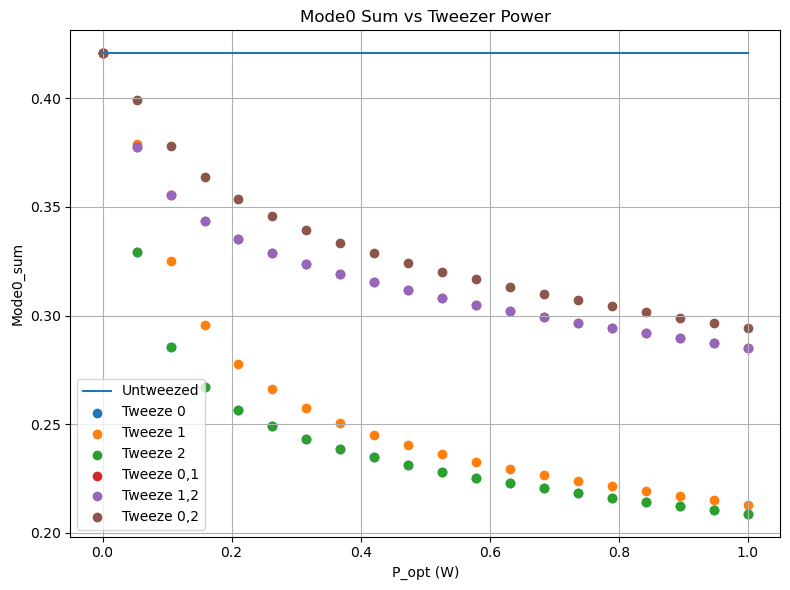

In [212]:
plt.figure(figsize=(8,6))

plt.plot(Untweezed['P_opt (W)'], Untweezed['Mode0_sum'], label="Untweezed")
plt.scatter(Tweeze0['P_opt (W)'], Tweeze0['Mode0_sum'], label="Tweeze 0")
plt.scatter(Tweeze1['P_opt (W)'], Tweeze1['Mode0_sum'], label="Tweeze 1")
plt.scatter(Tweeze2['P_opt (W)'], Tweeze2['Mode0_sum'], label="Tweeze 2")
plt.scatter(Tweeze01['P_opt (W)'], Tweeze01['Mode0_sum'], label="Tweeze 0,1")
plt.scatter(Tweeze12['P_opt (W)'], Tweeze12['Mode0_sum'], label="Tweeze 1,2")
plt.scatter(Tweeze02['P_opt (W)'], Tweeze02['Mode0_sum'], label="Tweeze 0,2")


plt.xlabel("P_opt (W)")
plt.ylabel("Mode0_sum")
plt.title("Mode0 Sum vs Tweezer Power")
plt.legend(loc = "best")
plt.grid(True)
plt.tight_layout()
plt.show()

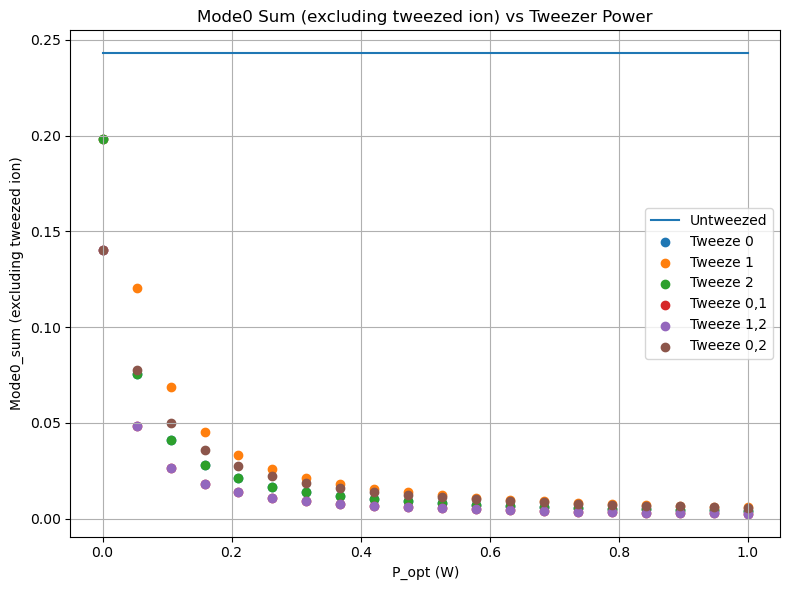

In [258]:
plt.figure(figsize=(8,6))

plt.plot(Untweezed['P_opt (W)'], Untweezed['Mode0_sum_no_tweeze'], label="Untweezed")
plt.scatter(Tweeze0['P_opt (W)'], Tweeze0['Mode0_sum_no_tweeze'], label="Tweeze 0")
plt.scatter(Tweeze1['P_opt (W)'], Tweeze1['Mode0_sum_no_tweeze'], label="Tweeze 1")
plt.scatter(Tweeze2['P_opt (W)'], Tweeze2['Mode0_sum_no_tweeze'], label="Tweeze 2")
plt.scatter(Tweeze01['P_opt (W)'], Tweeze01['Mode0_sum_no_tweeze'], label="Tweeze 0,1")
plt.scatter(Tweeze12['P_opt (W)'], Tweeze12['Mode0_sum_no_tweeze'], label="Tweeze 1,2")
plt.scatter(Tweeze02['P_opt (W)'], Tweeze02['Mode0_sum_no_tweeze'], label="Tweeze 0,2")


plt.xlabel("P_opt (W)")
plt.ylabel("Mode0_sum (excluding tweezed ion)")
plt.title("Mode0 Sum (excluding tweezed ion) vs Tweezer Power")
plt.legend(loc = "best")
plt.grid(True)
plt.tight_layout()
plt.show()

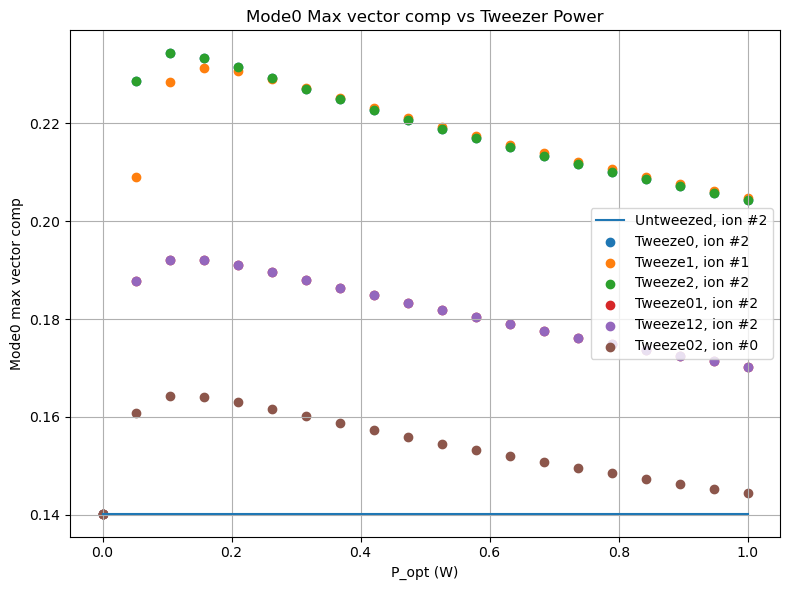

In [227]:
plt.figure(figsize=(8,6))

plt.plot(Untweezed['P_opt (W)'], Untweezed['Mode0_max'], label=f"Untweezed, ion #{Untweezed['Mode0_max_index'].iloc[2]}")
plt.scatter(Tweeze0['P_opt (W)'], Tweeze0['Mode0_max'],label = f"Tweeze0, ion #{Tweeze0['Mode0_max_index'].iloc[2]}")
plt.scatter(Tweeze1['P_opt (W)'], Tweeze1['Mode0_max'], label = f"Tweeze1, ion #{Tweeze1['Mode0_max_index'].iloc[2]}")
plt.scatter(Tweeze2['P_opt (W)'], Tweeze2['Mode0_max'], label = f"Tweeze2, ion #{Tweeze2['Mode0_max_index'].iloc[2]}")
plt.scatter(Tweeze01['P_opt (W)'], Tweeze01['Mode0_max'], label = f"Tweeze01, ion #{Tweeze01['Mode0_max_index'].iloc[2]}")
plt.scatter(Tweeze12['P_opt (W)'], Tweeze12['Mode0_max'], label = f"Tweeze12, ion #{Tweeze12['Mode0_max_index'].iloc[2]}")
plt.scatter(Tweeze02['P_opt (W)'], Tweeze02['Mode0_max'], label = f"Tweeze02, ion #{Tweeze02['Mode0_max_index'].iloc[2]}")


plt.xlabel("P_opt (W)")
plt.ylabel("Mode0 max vector comp")
plt.title("Mode0 Max vector comp vs Tweezer Power")
plt.legend(loc = "best")
plt.grid(True)
plt.tight_layout()
plt.show()

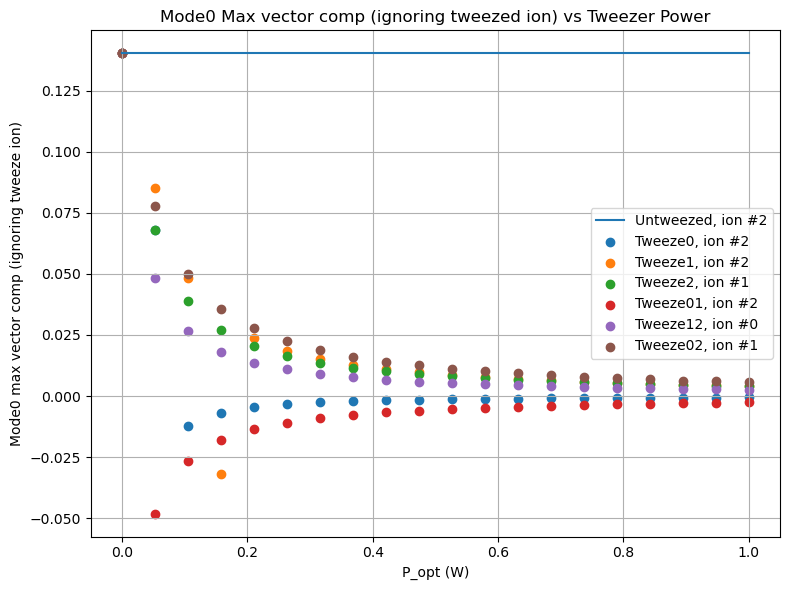

In [245]:
plt.figure(figsize=(8,6))

plt.plot(Untweezed['P_opt (W)'], Untweezed['Mode0_max_no_tweeze'], label=f"Untweezed, ion #{Untweezed['Mode0_max_no_tweeze_index'].iloc[2]}")
plt.scatter(Tweeze0['P_opt (W)'], Tweeze0['Mode0_max_no_tweeze'],label = f"Tweeze0, ion #{Tweeze0['Mode0_max_no_tweeze_index'].iloc[2]}")
plt.scatter(Tweeze1['P_opt (W)'], Tweeze1['Mode0_max_no_tweeze'], label = f"Tweeze1, ion #{Tweeze1['Mode0_max_no_tweeze_index'].iloc[2]}")
plt.scatter(Tweeze2['P_opt (W)'], Tweeze2['Mode0_max_no_tweeze'], label = f"Tweeze2, ion #{Tweeze2['Mode0_max_no_tweeze_index'].iloc[2]}")
plt.scatter(Tweeze01['P_opt (W)'], Tweeze01['Mode0_max_no_tweeze'], label = f"Tweeze01, ion #{Tweeze01['Mode0_max_no_tweeze_index'].iloc[2]}")
plt.scatter(Tweeze12['P_opt (W)'], Tweeze12['Mode0_max_no_tweeze'], label = f"Tweeze12, ion #{Tweeze12['Mode0_max_no_tweeze_index'].iloc[2]}")
plt.scatter(Tweeze02['P_opt (W)'], Tweeze02['Mode0_max_no_tweeze'], label = f"Tweeze02, ion #{Tweeze02['Mode0_max_no_tweeze_index'].iloc[2]}")


plt.xlabel("P_opt (W)")
plt.ylabel("Mode0 max vector comp (ignoring tweeze ion)")
plt.title("Mode0 Max vector comp (ignoring tweezed ion) vs Tweezer Power")
plt.legend(loc = "best")
plt.grid(True)
plt.tight_layout()
plt.show()

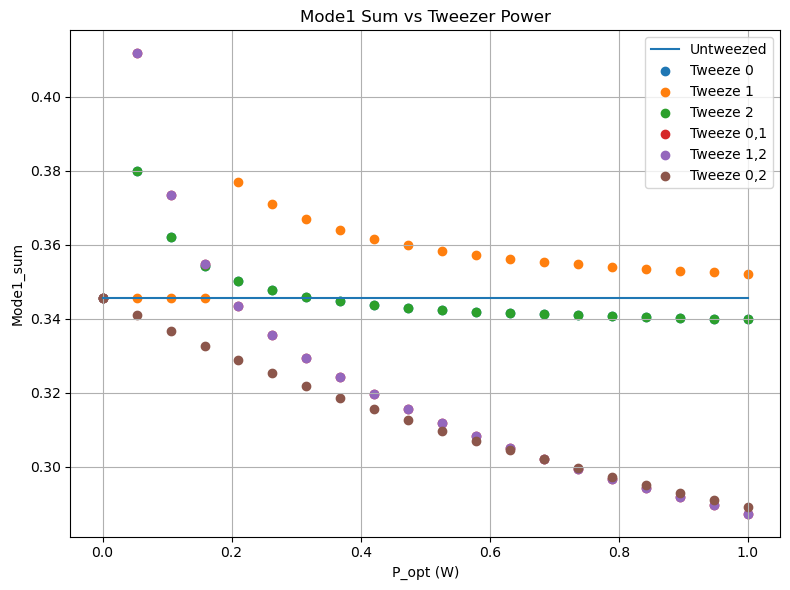

In [214]:
plt.figure(figsize=(8,6))

plt.plot(Untweezed['P_opt (W)'], Untweezed['Mode1_sum'], label="Untweezed")
plt.scatter(Tweeze0['P_opt (W)'], Tweeze0['Mode1_sum'], label="Tweeze 0")
plt.scatter(Tweeze1['P_opt (W)'], Tweeze1['Mode1_sum'], label="Tweeze 1")
plt.scatter(Tweeze2['P_opt (W)'], Tweeze2['Mode1_sum'], label="Tweeze 2")
plt.scatter(Tweeze01['P_opt (W)'], Tweeze01['Mode1_sum'], label="Tweeze 0,1")
plt.scatter(Tweeze12['P_opt (W)'], Tweeze12['Mode1_sum'], label="Tweeze 1,2")
plt.scatter(Tweeze02['P_opt (W)'], Tweeze02['Mode1_sum'], label="Tweeze 0,2")

plt.xlabel("P_opt (W)")
plt.ylabel("Mode1_sum")
plt.title("Mode1 Sum vs Tweezer Power")
plt.legend(loc = "best")
plt.grid(True)
plt.tight_layout()
plt.show()

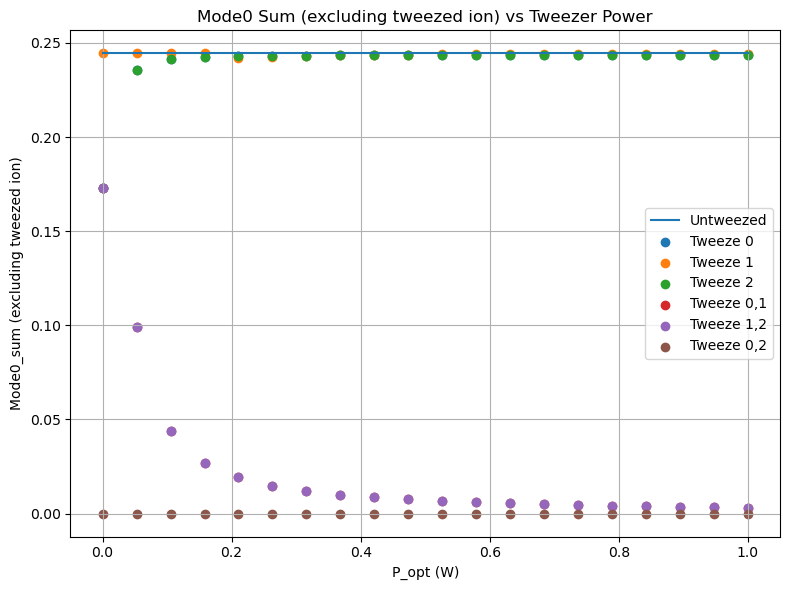

In [259]:
plt.figure(figsize=(8,6))

plt.plot(Untweezed['P_opt (W)'], Untweezed['Mode1_sum_no_tweeze'], label="Untweezed")
plt.scatter(Tweeze0['P_opt (W)'], Tweeze0['Mode1_sum_no_tweeze'], label="Tweeze 0")
plt.scatter(Tweeze1['P_opt (W)'], Tweeze1['Mode1_sum_no_tweeze'], label="Tweeze 1")
plt.scatter(Tweeze2['P_opt (W)'], Tweeze2['Mode1_sum_no_tweeze'], label="Tweeze 2")
plt.scatter(Tweeze01['P_opt (W)'], Tweeze01['Mode1_sum_no_tweeze'], label="Tweeze 0,1")
plt.scatter(Tweeze12['P_opt (W)'], Tweeze12['Mode1_sum_no_tweeze'], label="Tweeze 1,2")
plt.scatter(Tweeze02['P_opt (W)'], Tweeze02['Mode1_sum_no_tweeze'], label="Tweeze 0,2")


plt.xlabel("P_opt (W)")
plt.ylabel("Mode0_sum (excluding tweezed ion)")
plt.title("Mode0 Sum (excluding tweezed ion) vs Tweezer Power")
plt.legend(loc = "best")
plt.grid(True)
plt.tight_layout()
plt.show()

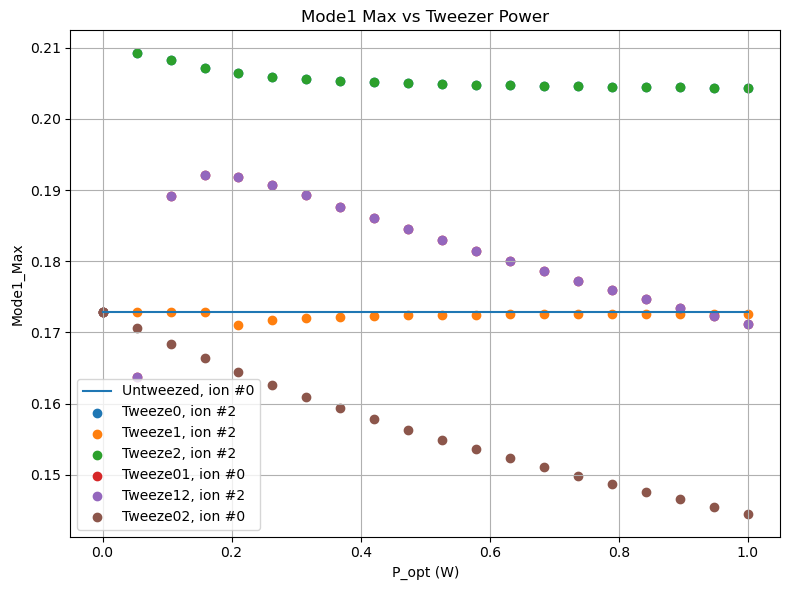

In [228]:
plt.figure(figsize=(8,6))

plt.plot(Untweezed['P_opt (W)'], Untweezed['Mode1_max'], label = f"Untweezed, ion #{Untweezed['Mode1_max_index'].iloc[2]}")
plt.scatter(Tweeze0['P_opt (W)'], Tweeze0['Mode1_max'],  label = f"Tweeze0, ion #{Tweeze0['Mode1_max_index'].iloc[2]}")
plt.scatter(Tweeze1['P_opt (W)'], Tweeze1['Mode1_max'],  label = f"Tweeze1, ion #{Tweeze1['Mode1_max_index'].iloc[2]}")
plt.scatter(Tweeze2['P_opt (W)'], Tweeze2['Mode1_max'],  label = f"Tweeze2, ion #{Tweeze1['Mode1_max_index'].iloc[2]}")
plt.scatter(Tweeze01['P_opt (W)'], Tweeze01['Mode1_max'],  label = f"Tweeze01, ion #{Tweeze01['Mode1_max_index'].iloc[2]}")
plt.scatter(Tweeze12['P_opt (W)'], Tweeze12['Mode1_max'],  label = f"Tweeze12, ion #{Tweeze12['Mode1_max_index'].iloc[2]}")
plt.scatter(Tweeze02['P_opt (W)'], Tweeze02['Mode1_max'],  label = f"Tweeze02, ion #{Tweeze02['Mode1_max_index'].iloc[2]}")

plt.xlabel("P_opt (W)")
plt.ylabel("Mode1_Max")
plt.title("Mode1 Max vs Tweezer Power")
plt.legend(loc = "best")
plt.grid(True)
plt.tight_layout()
plt.show()

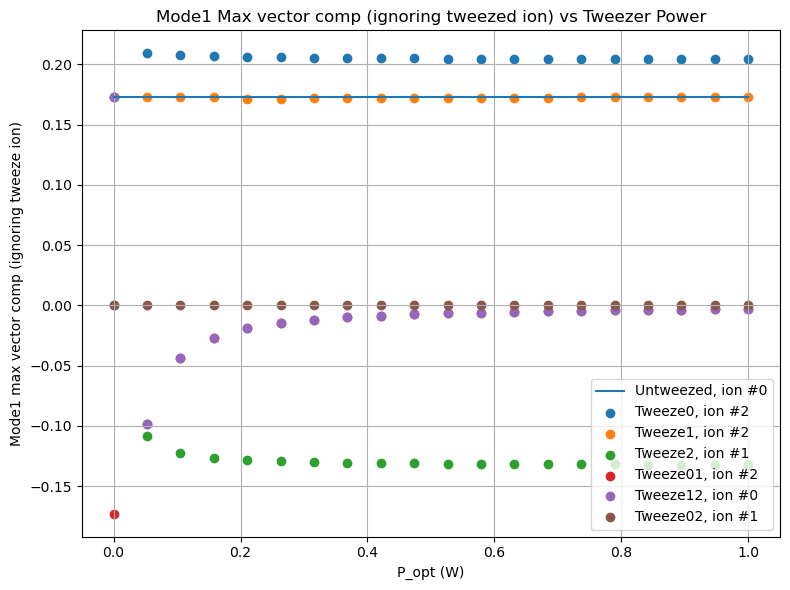

In [246]:
plt.figure(figsize=(8,6))

plt.plot(Untweezed['P_opt (W)'], Untweezed['Mode1_max_no_tweeze'], label=f"Untweezed, ion #{Untweezed['Mode1_max_no_tweeze_index'].iloc[2]}")
plt.scatter(Tweeze0['P_opt (W)'], Tweeze0['Mode1_max_no_tweeze'],label = f"Tweeze0, ion #{Tweeze0['Mode1_max_no_tweeze_index'].iloc[2]}")
plt.scatter(Tweeze1['P_opt (W)'], Tweeze1['Mode1_max_no_tweeze'], label = f"Tweeze1, ion #{Tweeze1['Mode1_max_no_tweeze_index'].iloc[2]}")
plt.scatter(Tweeze2['P_opt (W)'], Tweeze2['Mode1_max_no_tweeze'], label = f"Tweeze2, ion #{Tweeze2['Mode1_max_no_tweeze_index'].iloc[2]}")
plt.scatter(Tweeze01['P_opt (W)'], Tweeze01['Mode1_max_no_tweeze'], label = f"Tweeze01, ion #{Tweeze01['Mode1_max_no_tweeze_index'].iloc[2]}")
plt.scatter(Tweeze12['P_opt (W)'], Tweeze12['Mode1_max_no_tweeze'], label = f"Tweeze12, ion #{Tweeze12['Mode1_max_no_tweeze_index'].iloc[2]}")
plt.scatter(Tweeze02['P_opt (W)'], Tweeze02['Mode1_max_no_tweeze'], label = f"Tweeze02, ion #{Tweeze02['Mode1_max_no_tweeze_index'].iloc[2]}")


plt.xlabel("P_opt (W)")
plt.ylabel("Mode1 max vector comp (ignoring tweeze ion)")
plt.title("Mode1 Max vector comp (ignoring tweezed ion) vs Tweezer Power")
plt.legend(loc = "best")
plt.grid(True)
plt.tight_layout()
plt.show()

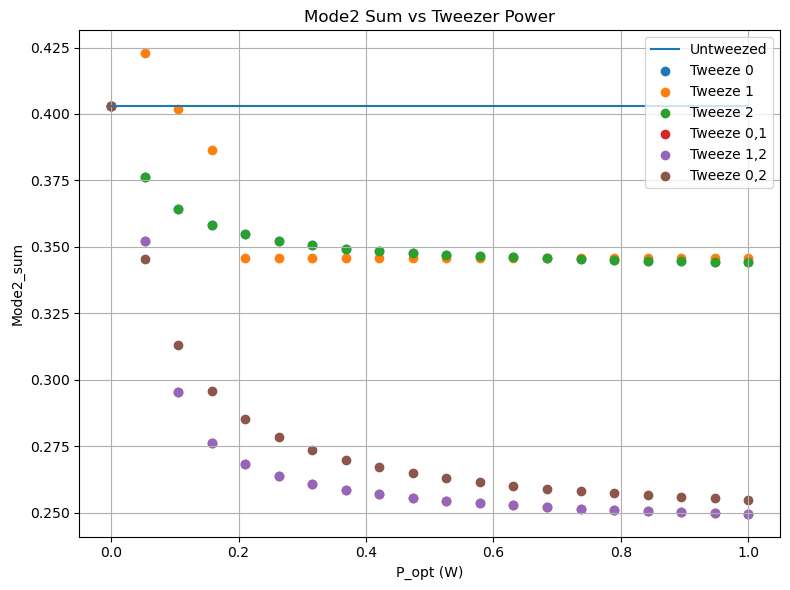

In [229]:
plt.figure(figsize=(8,6))

plt.plot(Untweezed['P_opt (W)'], Untweezed['Mode2_sum'], label="Untweezed")
plt.scatter(Tweeze0['P_opt (W)'], Tweeze0['Mode2_sum'], label="Tweeze 0")
plt.scatter(Tweeze1['P_opt (W)'], Tweeze1['Mode2_sum'], label="Tweeze 1")
plt.scatter(Tweeze2['P_opt (W)'], Tweeze2['Mode2_sum'], label="Tweeze 2")
plt.scatter(Tweeze01['P_opt (W)'], Tweeze01['Mode2_sum'], label="Tweeze 0,1")
plt.scatter(Tweeze12['P_opt (W)'], Tweeze12['Mode2_sum'], label="Tweeze 1,2")
plt.scatter(Tweeze02['P_opt (W)'], Tweeze02['Mode2_sum'], label="Tweeze 0,2")

plt.xlabel("P_opt (W)")
plt.ylabel("Mode2_sum")
plt.title("Mode2 Sum vs Tweezer Power")
plt.legend(loc = "best")
plt.grid(True)
plt.tight_layout()
plt.show()

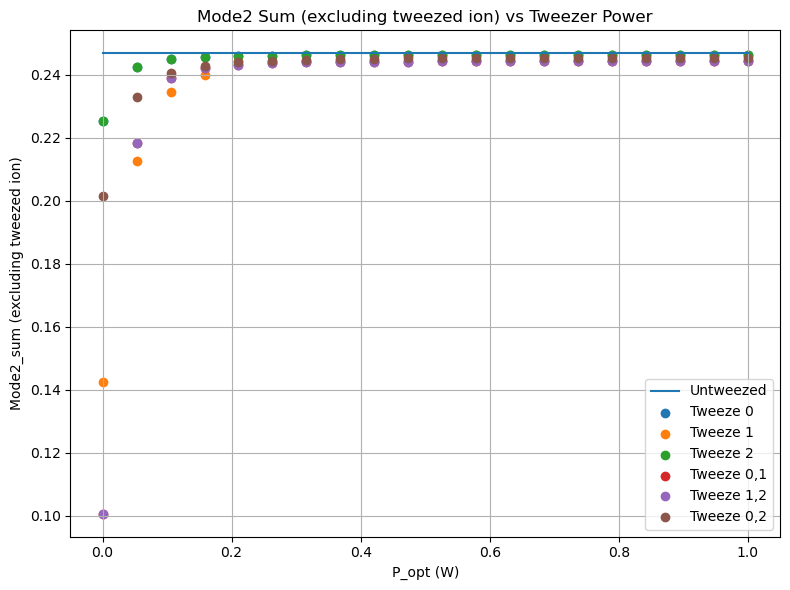

In [261]:
plt.figure(figsize=(8,6))

plt.plot(Untweezed['P_opt (W)'], Untweezed['Mode2_sum_no_tweeze'], label="Untweezed")
plt.scatter(Tweeze0['P_opt (W)'], Tweeze0['Mode2_sum_no_tweeze'], label="Tweeze 0")
plt.scatter(Tweeze1['P_opt (W)'], Tweeze1['Mode2_sum_no_tweeze'], label="Tweeze 1")
plt.scatter(Tweeze2['P_opt (W)'], Tweeze2['Mode2_sum_no_tweeze'], label="Tweeze 2")
plt.scatter(Tweeze01['P_opt (W)'], Tweeze01['Mode2_sum_no_tweeze'], label="Tweeze 0,1")
plt.scatter(Tweeze12['P_opt (W)'], Tweeze12['Mode2_sum_no_tweeze'], label="Tweeze 1,2")
plt.scatter(Tweeze02['P_opt (W)'], Tweeze02['Mode2_sum_no_tweeze'], label="Tweeze 0,2")


plt.xlabel("P_opt (W)")
plt.ylabel("Mode2_sum (excluding tweezed ion)")
plt.title("Mode2 Sum (excluding tweezed ion) vs Tweezer Power")
plt.legend(loc = "best")
plt.grid(True)
plt.tight_layout()
plt.show()

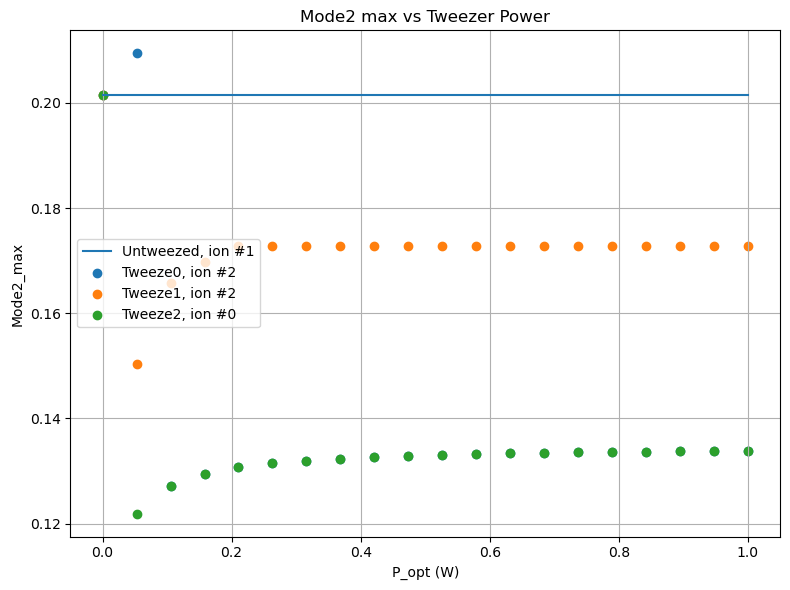

In [ ]:
plt.figure(figsize=(8,6))

plt.plot(Untweezed['P_opt (W)'], Untweezed['Mode2_max'], label = f"Untweezed, ion #{Untweezed['Mode2_max_index'].iloc[2]}")
plt.scatter(Tweeze0['P_opt (W)'], Tweeze0['Mode2_max'], label = f"Tweeze0, ion #{Tweeze0['Mode2_max_index'].iloc[2]}")
plt.scatter(Tweeze1['P_opt (W)'], Tweeze1['Mode2_max'],label = f"Tweeze1, ion #{Tweeze1['Mode2_max_index'].iloc[2]}")
plt.scatter(Tweeze2['P_opt (W)'], Tweeze2['Mode2_max'], label = f"Tweeze2, ion #{Tweeze2['Mode2_max_index'].iloc[2]}")
plt.scatter(Tweeze01['P_opt (W)'], Tweeze01['Mode2_max'], label = f"Tweeze01, ion #{Tweeze01['Mode2_max_index'].iloc[2]}")
plt.scatter(Tweeze12['P_opt (W)'], Tweeze12['Mode2_max'], label = f"Tweeze12, ion #{Tweeze12['Mode2_max_index'].iloc[2]}")
plt.scatter(Tweeze02['P_opt (W)'], Tweeze02['Mode2_max'], label = f"Tweeze02, ion #{Tweeze02['Mode2_max_index'].iloc[2]}")

plt.xlabel("P_opt (W)")
plt.ylabel("Mode2_max")
plt.title("Mode2 max vs Tweezer Power")
plt.legend(loc = "best")
plt.grid(True)
plt.tight_layout()
plt.show()

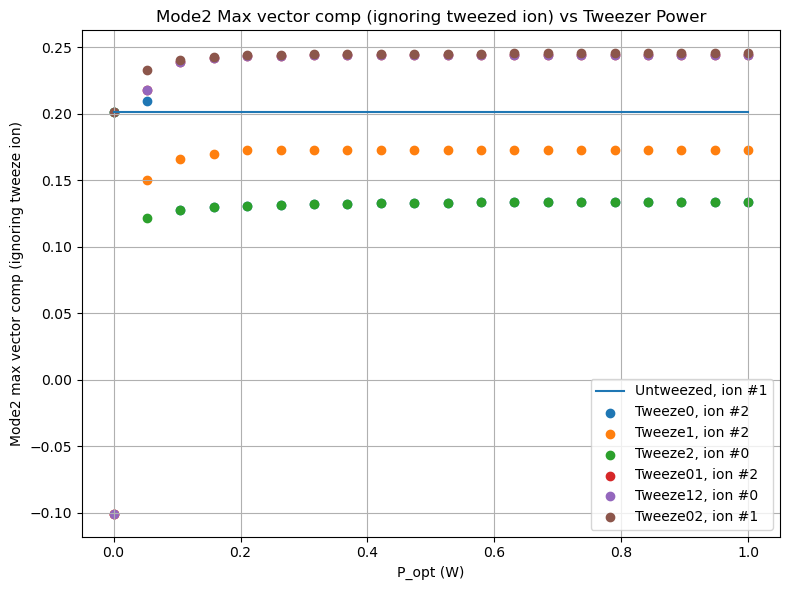

In [251]:
plt.figure(figsize=(8,6))

plt.plot(Untweezed['P_opt (W)'], Untweezed['Mode2_max_no_tweeze'], label=f"Untweezed, ion #{Untweezed['Mode2_max_no_tweeze_index'].iloc[2]}")
plt.scatter(Tweeze0['P_opt (W)'], Tweeze0['Mode2_max_no_tweeze'],label = f"Tweeze0, ion #{Tweeze0['Mode2_max_no_tweeze_index'].iloc[2]}")
plt.scatter(Tweeze1['P_opt (W)'], Tweeze1['Mode2_max_no_tweeze'], label = f"Tweeze1, ion #{Tweeze1['Mode2_max_no_tweeze_index'].iloc[2]}")
plt.scatter(Tweeze2['P_opt (W)'], Tweeze2['Mode2_max_no_tweeze'], label = f"Tweeze2, ion #{Tweeze2['Mode2_max_no_tweeze_index'].iloc[2]}")
plt.scatter(Tweeze01['P_opt (W)'], Tweeze01['Mode2_max_no_tweeze'], label = f"Tweeze01, ion #{Tweeze01['Mode2_max_no_tweeze_index'].iloc[2]}")
plt.scatter(Tweeze12['P_opt (W)'], Tweeze12['Mode2_max_no_tweeze'], label = f"Tweeze12, ion #{Tweeze12['Mode2_max_no_tweeze_index'].iloc[2]}")
plt.scatter(Tweeze02['P_opt (W)'], Tweeze02['Mode2_max_no_tweeze'], label = f"Tweeze02, ion #{Tweeze02['Mode2_max_no_tweeze_index'].iloc[2]}")


plt.xlabel("P_opt (W)")
plt.ylabel("Mode2 max vector comp (ignoring tweeze ion)")
plt.title("Mode2 Max vector comp (ignoring tweezed ion) vs Tweezer Power")
plt.legend(loc = "best")
plt.grid(True)
plt.tight_layout()
plt.show()